
Projeto: Segmentação de Imagens Médicas

Integrantes:
- Anshu Li - RA XXXXX
- Andrea - 10418084

Descrição:
Este notebook realiza a análise exploratória e preparação dos dados
de imagens médicas para segmentação.

Histórico:
- 23/03/2026 - Andrea e Anshu: Criação inicial


In [2]:
!pip install SimpleITK matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 16.2 MB/s eta 0:00:00


In [4]:
import os
import pandas as pd
import SimpleITK as sitk
import matplotlib.pyplot as plt
import numpy as np

caminho_arquivo = "Case00.mhd"
imagem_itk = sitk.ReadImage(caminho_arquivo)
numpy_img = sitk.GetArrayFromImage(imagem_itk)
print(f"Tamanho do volume: {numpy_img.shape}")
print(f"Valor máximo de cor: {np.max(numpy_img)}")

Tamanho do volume: (20, 320, 320)
Valor máximo de cor: 1831


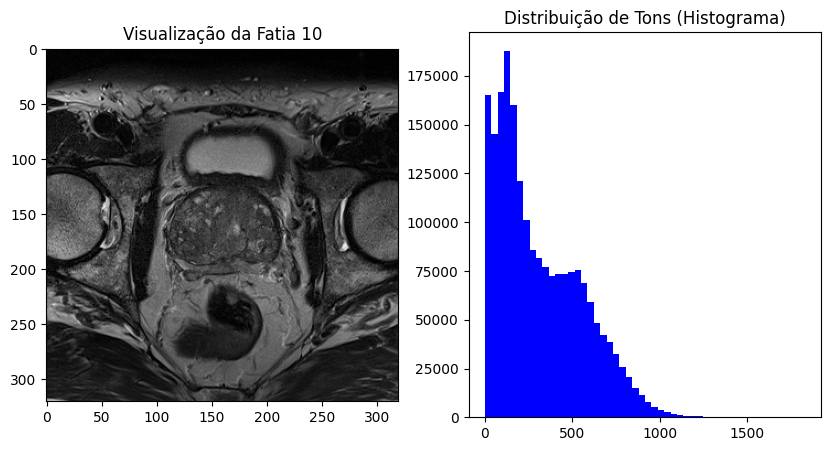

In [5]:
fatia_do_meio = numpy_img[10]
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(fatia_do_meio, cmap='gray')
plt.title("Visualização da Fatia 10")
plt.subplot(1, 2, 2)
plt.hist(numpy_img.flatten(), bins=50, color='blue')
plt.title("Distribuição de Tons (Histograma)")
plt.show()

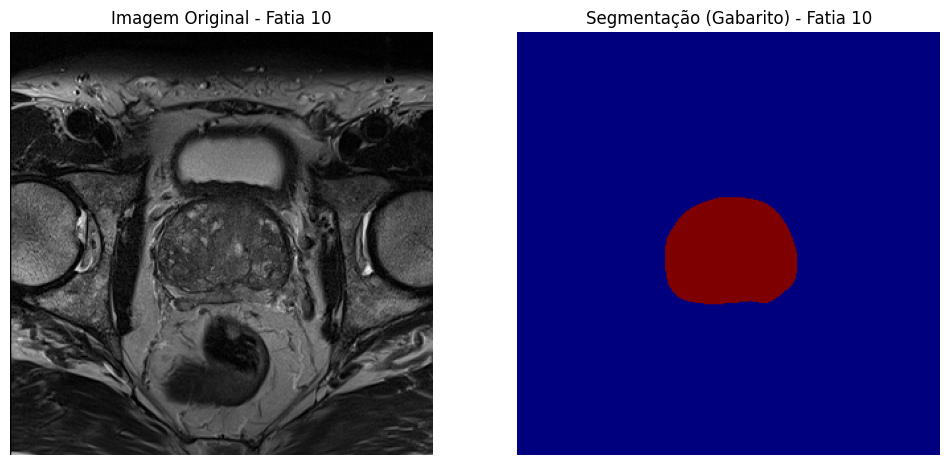

In [7]:
img_original = sitk.ReadImage("Case00.mhd")
img_mask = sitk.ReadImage("Case00_segmentation.mhd")
array_original = sitk.GetArrayFromImage(img_original)
array_mask = sitk.GetArrayFromImage(img_mask)
fatia = 10
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(array_original[fatia], cmap='gray')
plt.title(f"Imagem Original - Fatia {fatia}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(array_mask[fatia], cmap='jet')
plt.title(f"Segmentação (Gabarito) - Fatia {fatia}")
plt.axis('off')

plt.show()

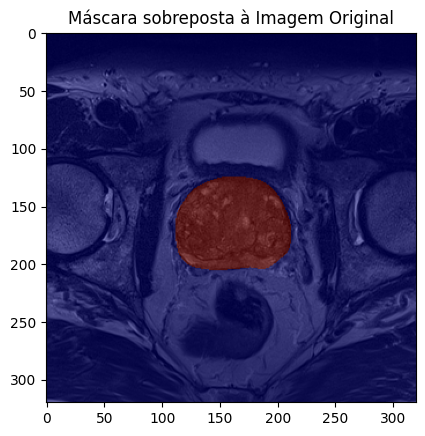

In [9]:
plt.imshow(array_original[fatia], cmap='gray')
plt.imshow(array_mask[fatia], cmap='jet', alpha=0.5)
plt.title("Máscara sobreposta à Imagem Original")
plt.show()

In [8]:

labels = np.unique(array_mask)
print(f"Valores encontrados na máscara: {labels}")

Valores encontrados na máscara: [0 1]


In [12]:
diretorio = "Data"
lista_metadados = []
volumes_segmentados = []
for arquivo in sorted(os.listdir(diretorio)):
    if arquivo.endswith(".mhd"):
        caminho_completo = os.path.join(diretorio, arquivo)
        img = sitk.ReadImage(caminho_completo)
        if "segmentation" not in arquivo:
            lista_metadados.append({
                "Caso": arquivo.replace(".mhd", ""),
                "Largura": img.GetWidth(),
                "Altura": img.GetHeight(),
                "Slices (Z)": img.GetDepth(),
                "Voxel_Size_Z": round(img.GetSpacing()[2], 3)
            })
        else:
            mask_array = sitk.GetArrayFromImage(img)
            pixels_alvo = np.count_nonzero(mask_array)
            volumes_segmentados.append(pixels_alvo)


In [13]:
# Tabela de Consistência
df_stats = pd.DataFrame(lista_metadados)
print("\n RESUMO ESTATÍSTICO DO DATASET ")
display(df_stats.describe())


### RESUMO ESTATÍSTICO DO DATASET ###


,Largura,Altura,Slices (Z),Voxel_Size_Z
count,30.000000,30.000000,30.000000,30.000000
mean,416.000000,416.000000,26.500000,3.273333
std,97.641145,97.641145,8.203237,0.453289
min,320.000000,320.000000,19.000000,2.200000
25%,320.000000,320.000000,23.000000,3.300000
50%,416.000000,416.000000,24.000000,3.450000
75%,512.000000,512.000000,24.750000,3.600000
max,512.000000,512.000000,52.000000,3.600000


Text(0, 0.5, 'Contagem de Pixels')

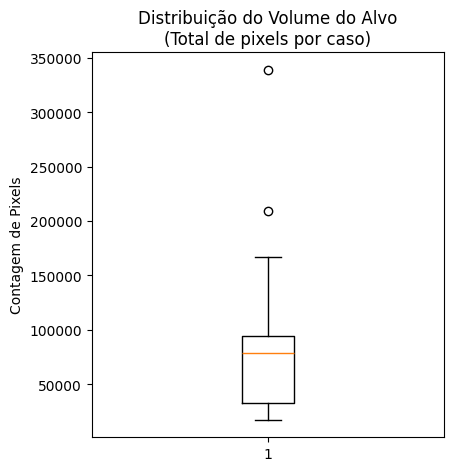

In [14]:
# Gráfico de Volume das Segmentações
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.boxplot(volumes_segmentados)
plt.title("Distribuição do Volume do Alvo\n(Total de pixels por caso)")
plt.ylabel("Contagem de Pixels")

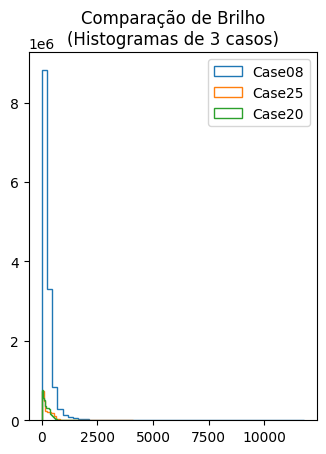

In [15]:
# Histograma de Comparação (Sorteia 3 casos)
plt.subplot(1, 2, 2)
casos_exemplo = df_stats["Caso"].sample(3).values
for caso in casos_exemplo:
    img_ex = sitk.ReadImage(os.path.join(diretorio, f"{caso}.mhd"))
    arr_ex = sitk.GetArrayFromImage(img_ex)
    plt.hist(arr_ex.flatten(), bins=50, histtype='step', label=caso)
plt.title("Comparação de Brilho\n(Histogramas de 3 casos)")
plt.legend()
plt.tight_layout()
plt.show()

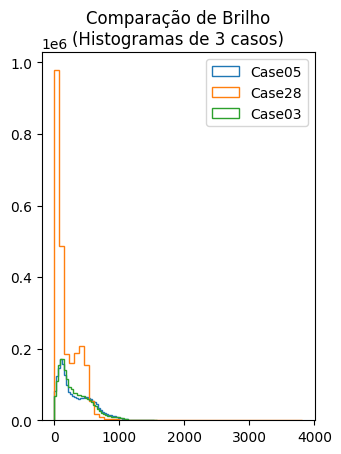

In [19]:
# Histograma de Comparação (Sorteia 3 casos)
plt.subplot(1, 2, 2)
casos_exemplo = df_stats["Caso"].sample(3).values
for caso in casos_exemplo:
    img_ex = sitk.ReadImage(os.path.join(diretorio, f"{caso}.mhd"))
    arr_ex = sitk.GetArrayFromImage(img_ex)
    plt.hist(arr_ex.flatten(), bins=50, histtype='step', label=caso)

plt.title("Comparação de Brilho\n(Histogramas de 3 casos)")
plt.legend()
plt.tight_layout()
plt.show()
